# QUALITY MANAGEMENT
# Athens Metro Line 1 — Ridership & Capacity Simulation

## Overview

This notebook simulates and estimates passenger demand on [**Line 1 (Kifissia–Piraeus)**](https://en.wikipedia.org/wiki/Line_1_(Athens_Metro)) during weekday operations (Monday through Friday). Since there are limited open ridership data available for this line, our model is built on parameters derived from available literature, web sources, and observed patterns.

## Project Context

This notebook is part of a university project (Quality Management Course) aimed at identifying and analyzing a quality issue experienced by students in their daily life, and applying **Quality Management methodology** to propose solutions (e.g., Ishikawa diagrams).

## Scope

- **Period:** Spring semester, academic year 2025–2026  
- **Days covered:** Weekdays only (Monday–Friday)  
- **Exclusions:** Public holidays

## Imports
Following standard practice, and for the convenience of the reader, all imports will be placed at the beginning in the cell below.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import random
import math
import json

The data below originate from the analysis stored at `line1_data.ipynb`.

In [2]:
with open("sim_params.json") as f:
    sim_params = json.load(f)

day_multipliers = sim_params["day_multipliers"]
hourly_weights  = {int(k): v for k, v in sim_params["hourly_weights"].items()}  # keys come back as strings from JSON
peak_hours      = set(sim_params["peak_hours"])
incident_prob   = sim_params["incident_prob"]

print("Day multipliers:", day_multipliers)
print("Incident prob:", incident_prob)
print("Peak hours:", sorted(peak_hours))
print("Hourly weights:", hourly_weights)

Day multipliers: [1.044, 0.985, 1.0, 0.991, 0.8]
Incident prob: 0.0882
Peak hours: [8, 9, 10, 15, 16, 17, 18, 19]
Hourly weights: {0: 0.015, 1: 0.0021, 2: 0.0001, 3: 0.0, 4: 0.0, 5: 0.0011, 6: 0.0171, 7: 0.0451, 8: 0.0681, 9: 0.0766, 10: 0.0593, 11: 0.0498, 12: 0.0518, 13: 0.0518, 14: 0.0542, 15: 0.0647, 16: 0.0724, 17: 0.0764, 18: 0.077, 19: 0.0665, 20: 0.0509, 21: 0.0431, 22: 0.0348, 23: 0.0222}


## Schedule

Service patterns are modelled on the official [STASY Line 1 timetable](https://www.stasy.gr/%CE%B4%CF%81%CE%BF%CE%BC%CE%BF%CE%BB%CF%8C%CE%B3%CE%B9%CE%B1/%CE%B3%CF%81%CE%B1%CE%BC%CE%BC%CE%AE-1/),
with frequency and cancellation parameters calibrated against observed boarding patterns
recorded on the line during **February–April 2026**.

Hourly demand distribution is informed by open validation data published on
[data.gov.gr](https://www.data.gov.gr), which reveals two distinct demand peaks:

| Period | Hours | Type |
|---|---|---|
| Morning peak | 09:00 – 11:00 | Secondary peak |
| Evening peak | 16:00 – 20:00 | Dominant peak (busiest hour: ~19:00) |


The line operates daily from **05:30 to 00:30**,
covering 26 stations across approximately 25.6 km between Kifissia (north) and
Piraeus (south), passing through central Athens.

In [3]:
schedule = [
    #start    end    sched_freq  actual_freq  loss_pct  is_peak
    #frequencies in minutes between trains
    #loss_pct = base cancellation rate before peak/day multipliers
    ["05:00", "05:30",   15,       15.5,        0.01,    False],
    ["05:30", "07:00",   7.5,       8,        0.01,    False],
    ["07:00", "08:00",    6,        6.5,         0.03,    False],
    ["08:00", "10:00",    6,        6.5,         0.05,    True], #morning peak (empirical: 09-10 highest AM hour)
    ["10:00", "15:00",    7.5,        8,         0.01,    False],
    ["15:00", "16:00",    6,        6.5,         0.02,    True],
    ["16:00", "18:00",    6,        6.5,         0.07,    True], #dominant evening peak (empirical: 17-19 busiest)
    ["18:00", "19:00",    7.5,        8,         0.07,    True], #dominant evening peak (empirical: 17-19 busiest)
    ["19:00", "22:30",    7.5,        8,         0.02,    False],
    ["22:30", "23:30",   12,       12.5,         0.01,    False],
    ["23:30", "01:30",   15,       15.5,         0.01,    False],
]

## Simulation Core — Day Model

Day-of-week multipliers are derived directly from real STASY validation data,
with **Wednesday as the baseline (1.0)**.

| Day | Mon | Tue | Wed | Thu | Fri |
|---|---|---|---|---|---|
| Multiplier | 1.044 | 0.985 | 1.000 | 0.991 | 0.800 |

Punctuality is defined as departure within **3 minutes** of schedule. A 3-minute threshold is appropriate for the Athens Metro because urban and commuter rail systems typically define punctuality within “3–5–6 min, depending on the country” [(Denti and Burroni, 2023)](https://www.mdpi.com/2276034) . Choosing the lower bound reflects that “passengers…are much less tolerant” and perceive even small delays negatively [(Denti and Burroni, 2023)](https://www.mdpi.com/2276034).

Delays follow a **log-normal distribution** (non-negative, heavy right tail) and
**cascade** between consecutive trips at a 40% bleed rate.

Cancellation rates are scaled by both peak status (1.6× peak / 0.8× off-peak)
and the day-of-week multiplier, so busier days carry proportionally higher disruption pressure.

In [4]:
#on-time threshold: 3 minutes
ON_TIME_THRESHOLD_MIN = 3.0

def time_to_minutes(t):
    h, m = map(int, t.split(":"))
    return h * 60 + m

def lognormal(mu, sigma):
    #a lot of small delays, few large delays 
    return random.lognormvariate(mu, sigma)

def simulate_day(day_index, incident_prob=0.02, weather_factor=1.0, cascade_bleed=0.4):
    #Simulate one operating day for Line 1.
    #Returns daily KPIs AND per-slot records (for consistent slot breakdown).
    day_mult = day_multipliers[day_index % 5]
    sched_total = 0
    actual_total = 0
    cancelled_total = 0
    frequency_gap_total = 0
    incidents = 0
    delays = []
    prev_delay = 0
    slot_records = []

    #sf -> scheduled frequency
    #af -> actual frequency
    for start, end, sf, af, loss_pct, is_peak in schedule:
        sm = time_to_minutes(start)
        em = time_to_minutes(end)
        if em < sm:
            em += 24 * 60
        duration = em - sm

        sched = int(duration / sf) #planned number of trains
        actual_raw = int(duration / af) #trains that could run given the spacing
        peak_mult = 1.6 * day_mult if is_peak else 0.8 * day_mult

        #simulate cancelation rate based on weekday performance, weather, hour of day and randomness
        loss_pct_actual = max(0, random.gauss(loss_pct * (1 + 0.5*(weather_factor - 1)) *
                                                  (1.6 if is_peak else 0.8), 0.02))
        
        frequency_gap = sched - actual_raw # trains lost to wider headway
        cancelled = int(sched * loss_pct_actual) # trains cancelled on top of gap
        actual = max(0, sched - frequency_gap - cancelled) # trains that actually run

        sched_total += sched
        actual_total += actual
        cancelled_total += cancelled
        frequency_gap_total += frequency_gap

        slot_records.append({
            "slot": f"{start}\u2013{end}",
            "scheduled": sched,
            "actual": actual,
            "cancelled": cancelled,
            "is_peak": is_peak
        })

        for _ in range(actual):
            #delay per train based on day, weather and randomness
            delay = lognormal(0.3, 0.7) * peak_mult * weather_factor
            delay += prev_delay * cascade_bleed
            if random.random() < incident_prob:
                delay += random.uniform(5, 25)
                incidents += 1
            delay = max(0, delay)
            prev_delay = delay
            delays.append(delay)
        prev_delay *= 0.3 #partial impact of delay between time-slots

    avg_delay = sum(delays) / len(delays)
    on_time_pct = sum(1 for d in delays if d < ON_TIME_THRESHOLD_MIN) / len(delays) * 100

    return {
        "scheduled": sched_total,
        "actual": actual_total,
        "cancelled": cancelled_total,
        "avg_delay_min": round(avg_delay, 2),
        "on_time_pct": round(on_time_pct, 1),
        "incidents": incidents,
        "slot_records": slot_records
    }

## Simulation Run — 33 Workdays (Feb–Apr 2026)

The simulation covers **33 workdays** from 16 February to 3 April 2026.

Weather conditions are sampled probabilistically per month, reflecting Athens'
typical late-winter/early-spring climate:

| Month | Rain probability | Storm probability |
|---|---|---|
| February | 25% | 5% |
| March | 20% | 3% |
| April | 12% | 1% |

A storm applies a **1.5× delay multiplier**; rain applies **1.1×**; clear weather has no effect.
Each day is simulated independently with `incident_prob = 0.02` (2% chance per trip).

In [5]:
greek_holidays = ["2026-02-23", "2026-03-25"]
all_bdays = pd.bdate_range("2026-02-16", "2026-04-04")
workdays = [d for d in all_bdays if str(d.date()) not in greek_holidays][:33]

print(f"Simulation window: {workdays[0].date()} → {workdays[-1].date()}")
print(f"Total workdays: {len(workdays)}\n")

def get_weather(month):
    probs = {2: (0.25, 0.05), 3: (0.20, 0.03), 4: (0.12, 0.01)}
    rain_p, storm_p = probs.get(month, (0.20, 0.02))
    r = random.random()
    if r < storm_p:            return ("storm", 1.5)
    elif r < storm_p + rain_p: return ("rain",  1.1)
    else:                      return ("clear", 1.0)

cascade_bleed  = 0.4
random.seed(42)
results = []
for date in workdays:
    weather_condition, weather_factor = get_weather(date.month)
    r = simulate_day(date.weekday(), incident_prob, weather_factor, cascade_bleed)
    r["date"]    = date
    r["weekday"] = date.day_name()
    r["month"]   = date.strftime("%B")
    r["weather"] = weather_condition
    results.append(r)

for i, r in enumerate(results, 1):
    print(f"Day {i:>2} ({r['weekday'][:3]} {r['date'].strftime('%d %b')}) [{r['weather']:<5}]: "
          f"ran {r['actual']}/{r['scheduled']} | "
          f"cancelled {r['cancelled']} | "
          f"avg delay {r['avg_delay_min']} min | "
          f"on-time {r['on_time_pct']}% | "
          f"incidents {r['incidents']}")

print("\n--- 33-Day Averages ---")
n = len(results)
for key in ["scheduled", "actual", "cancelled", "avg_delay_min", "on_time_pct", "incidents"]:
    print(f"  {key}: {sum(r[key] for r in results)/n:.2f}")

Simulation window: 2026-02-16 → 2026-04-03
Total workdays: 33

Day  1 (Mon 16 Feb) [clear]: ran 143/163 | cancelled 4 | avg delay 4.48 min | on-time 53.8% | incidents 10
Day  2 (Tue 17 Feb) [clear]: ran 146/163 | cancelled 1 | avg delay 4.56 min | on-time 47.3% | incidents 7
Day  3 (Wed 18 Feb) [clear]: ran 143/163 | cancelled 4 | avg delay 5.04 min | on-time 48.3% | incidents 14
Day  4 (Thu 19 Feb) [rain ]: ran 142/163 | cancelled 5 | avg delay 5.43 min | on-time 40.8% | incidents 11
Day  5 (Fri 20 Feb) [rain ]: ran 143/163 | cancelled 4 | avg delay 4.88 min | on-time 51.7% | incidents 15
Day  6 (Tue 24 Feb) [clear]: ran 143/163 | cancelled 4 | avg delay 5.42 min | on-time 39.9% | incidents 12
Day  7 (Wed 25 Feb) [clear]: ran 144/163 | cancelled 3 | avg delay 4.93 min | on-time 45.8% | incidents 11
Day  8 (Thu 26 Feb) [rain ]: ran 144/163 | cancelled 3 | avg delay 4.83 min | on-time 44.4% | incidents 13
Day  9 (Fri 27 Feb) [clear]: ran 141/163 | cancelled 6 | avg delay 4.79 min | on-t

## Per-Slot Breakdown

Trip counts are aggregated by time slot across all 33 simulated days.
The `suppressed` column captures all trips that did not run —
whether cancelled outright or lost to the frequency gap between scheduled and actual headways.

The evening peak slot (**16:00–20:00**) consistently shows the highest absolute cancellations,
reflecting both its longer duration and its elevated cancellation rate multiplier.

In [6]:
all_slot_records = []
for r in results:
    all_slot_records.extend(r["slot_records"])

slot_order = [f"{s}\u2013{e}" for s, e, *_ in schedule]

slot_df = pd.DataFrame(all_slot_records)
avg_by_slot = (
    slot_df.groupby("slot")[["scheduled", "actual", "cancelled"]]
    .mean()
    .round(2)
    .reindex(slot_order)
)
avg_by_slot["cancellation_rate"] = (
    slot_df.groupby("slot")["cancelled"].sum() /
    slot_df.groupby("slot")["scheduled"].sum()
    * 100
).round(1)
avg_by_slot["suppressed"] = (
    avg_by_slot["scheduled"] - avg_by_slot["actual"]
).round(2)

avg_by_slot

,scheduled,actual,cancelled,cancellation_rate,suppressed
slot,,,,,
05:00–05:30,2.0,1.00,0.00,0.0,1.00
05:30–07:00,12.0,11.00,0.00,0.0,1.00
07:00–08:00,10.0,9.00,0.00,0.0,1.00
08:00–10:00,20.0,16.88,1.12,5.6,3.12
10:00–15:00,40.0,36.88,0.12,0.3,3.12
15:00–16:00,10.0,8.97,0.03,0.3,1.03
16:00–18:00,20.0,16.18,1.82,9.1,3.82
18:00–19:00,8.0,6.70,0.30,3.8,1.30
19:00–22:30,28.0,25.76,0.24,0.9,2.24


## Capacity Estimation

Line 1 operates three rolling [stock variants](https://el.wikipedia.org/wiki/%CE%A4%CF%81%CE%BF%CF%87%CE%B1%CE%AF%CE%BF_%CF%85%CE%BB%CE%B9%CE%BA%CF%8C_%CE%BC%CE%B5%CF%84%CF%81%CF%8C_%CE%91%CE%B8%CE%AE%CE%BD%CE%B1%CF%82#%CE%93%CF%81%CE%B1%CE%BC%CE%BC%CE%AE_1) with different passenger capacities.
Each branch contributes to a fleet-weighted average capacity per train:

| Branch | Capacity (pax) | Fleet share |
|---|---|---|
| Branch 8 | 830 | 25% |
| Branch 11 | 1,002 | 60% |
| Branch 1 | 1,030 | 15% |

**Weighted average capacity: ~963 passengers per train.**

This figure is multiplied by the average actual and scheduled trip counts per slot
to estimate total passenger capacity offered — the maximum number of passengers
the line could carry under each scenario. It should be noted that fleet share % does not
come from an actual statistic but from observation.

In [7]:
branches = {
    'branch_8':  (830, 1330, 0.25),
    'branch_11': (1002, 1302, 0.60),
    'branch_1':  (1030, 1330, 0.15),
}

total_weight = sum(w for p, cap, w in branches.values())
assert abs(total_weight - 1.0) < 1e-9, f"Branch weights must sum to 1.0, got {total_weight}"

avg_capacity_limited = sum(p * w for p, cap, w in branches.values())
avg_capacity_reality = sum(cap * w for p, cap, w in branches.values())

slot_durations = {
    '05:00–05:30': 0.5, '05:30–07:00': 1.5, '07:00–08:00': 1, '08:00–10:00': 2,
    '10:00–15:00': 5, '15:00–16:00': 1, '16:00–18:00': 2, '18:00–19:00': 1,
    '19:00–22:30': 3.5, '22:30–23:30': 1, '23:30–01:30': 2,
}

#avg_by_slot['slot_hours'] = avg_by_slot.index.map(slot_durations)
avg_by_slot['capacity_actual']    = (avg_by_slot['actual']    * avg_capacity_limited).round(0)
avg_by_slot['capacity_reality'] = (avg_by_slot['actual'] * avg_capacity_reality).round(0)
avg_by_slot['capacity_scheduled'] = (avg_by_slot['scheduled'] * avg_capacity_limited).round(0)

In [8]:
def slot_demand_weight(start, end):
    sm_min = time_to_minutes(start)
    em_min = time_to_minutes(end)
    if em_min < sm_min:  #genuine overnight (e.g. 23:30–01:30)
        em_min += 24 * 60

    sm = sm_min // 60
    em = em_min // 60  #exclusive upper bound

    return sum(hourly_weights.get(h % 24, 0) for h in range(sm, em))

In [9]:
REAL_DAILY_BOARDINGS = 213_950
ONE_DIR_BOARDINGS = REAL_DAILY_BOARDINGS / 2

avg_by_slot["demand_weight"] = [
    slot_demand_weight(s, e) for s, e, *_ in schedule
]
avg_by_slot["estimated_demand"] = (
    avg_by_slot["demand_weight"] * ONE_DIR_BOARDINGS
).round(0)

avg_by_slot["load_factor"] = (
    avg_by_slot["estimated_demand"] / avg_by_slot["capacity_actual"]
).round(3)

In [10]:
avg_by_slot

,scheduled,actual,cancelled,cancellation_rate,suppressed,capacity_actual,capacity_reality,capacity_scheduled,demand_weight,estimated_demand,load_factor
slot,,,,,,,,,,,
05:00–05:30,2.0,1.00,0.00,0.0,1.00,963.0,1313.0,1926.0,0.0000,0.0,0.000
05:30–07:00,12.0,11.00,0.00,0.0,1.00,10595.0,14445.0,11558.0,0.0182,1947.0,0.184
07:00–08:00,10.0,9.00,0.00,0.0,1.00,8669.0,11819.0,9632.0,0.0451,4825.0,0.557
08:00–10:00,20.0,16.88,1.12,5.6,3.12,16259.0,22167.0,19264.0,0.1447,15479.0,0.952
10:00–15:00,40.0,36.88,0.12,0.3,3.12,35523.0,48431.0,38528.0,0.2669,28552.0,0.804
15:00–16:00,10.0,8.97,0.03,0.3,1.03,8640.0,11779.0,9632.0,0.0647,6921.0,0.801
16:00–18:00,20.0,16.18,1.82,9.1,3.82,15585.0,21248.0,19264.0,0.1488,15918.0,1.021
18:00–19:00,8.0,6.70,0.30,3.8,1.30,6453.0,8798.0,7706.0,0.0770,8237.0,1.276
19:00–22:30,28.0,25.76,0.24,0.9,2.24,24812.0,33828.0,26970.0,0.1605,17169.0,0.692


In [11]:
print(f"Avg daily capacity (actual):    {avg_by_slot['capacity_actual'].sum():,.0f}")
print(f"Avg daily capacity (scheduled): {avg_by_slot['capacity_scheduled'].sum():,.0f}")
print(f"Avg daily capacity (no boarding limits): {avg_by_slot['capacity_reality'].sum():,.0f}")
print(f"Avg daily demand (real data, total):     {REAL_DAILY_BOARDINGS:,.0f}")
print(f"Avg daily demand (one direction):        {ONE_DIR_BOARDINGS:,.0f}")
print(f"Overall load factor:                     {ONE_DIR_BOARDINGS / avg_by_slot['capacity_reality'].sum():.3f}")

Avg daily capacity (actual):    138,094
Avg daily capacity (scheduled): 157,002
Avg daily capacity (no boarding limits): 188,273
Avg daily demand (real data, total):     213,950
Avg daily demand (one direction):        106,975
Overall load factor:                     0.568


## Visualisations

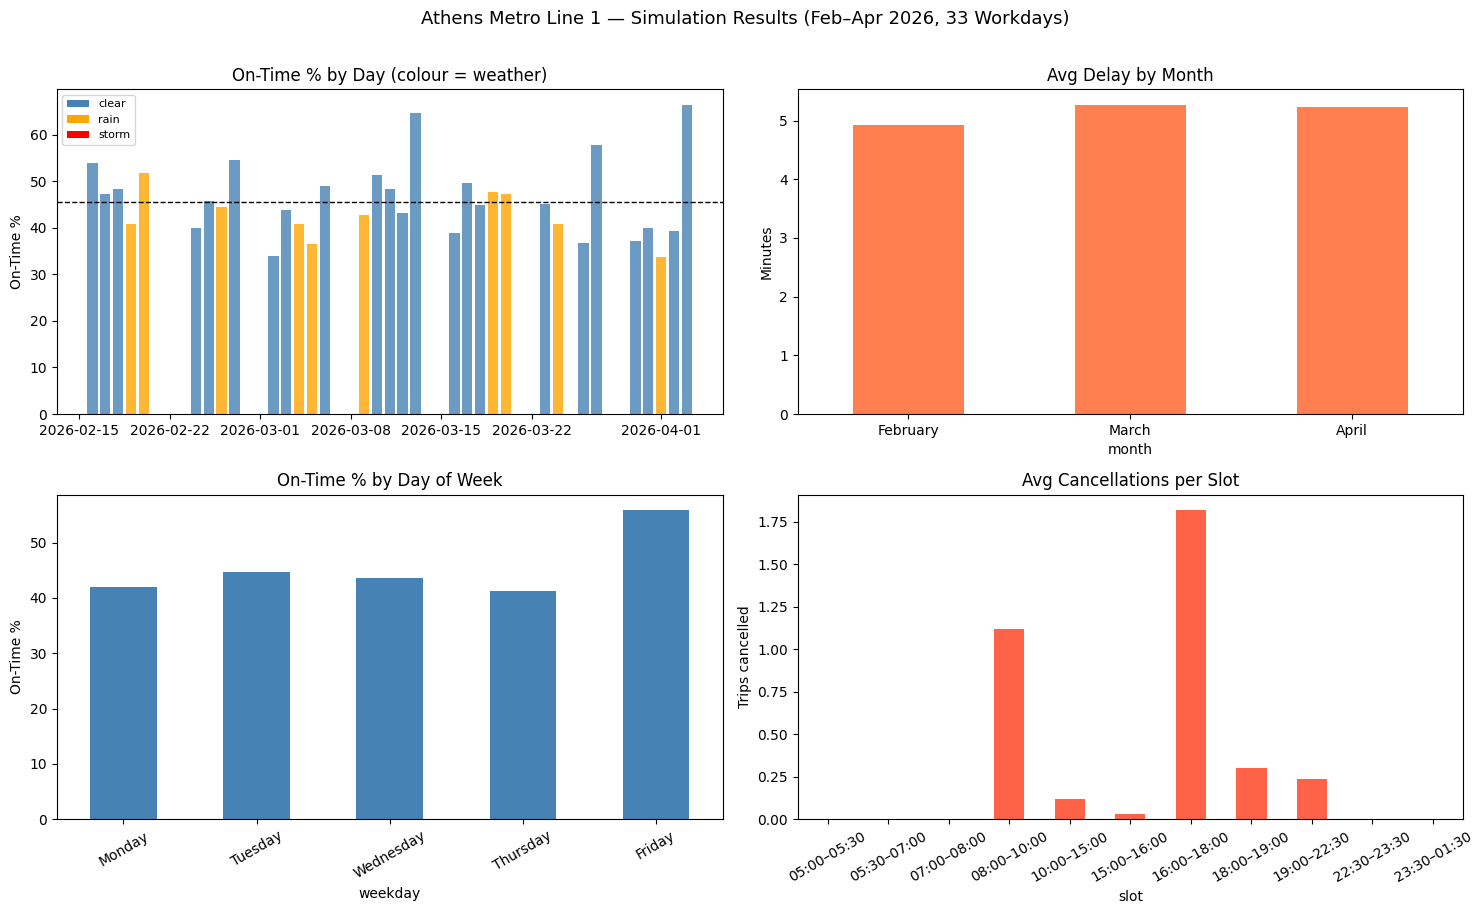

In [12]:
df = pd.DataFrame([{k: v for k, v in r.items() if k != 'slot_records'} for r in results])
df = df.set_index("date")

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle("Athens Metro Line 1 — Simulation Results (Feb–Apr 2026, 33 Workdays)", fontsize=13, y=1.01)

# 1. On-time % over time, coloured by weather
colors = {"clear": "steelblue", "rain": "orange", "storm": "red"}
for _, row in df.iterrows():
    axes[0,0].bar(row.name, row["on_time_pct"], color=colors[row["weather"]], alpha=0.8)
axes[0,0].axhline(df["on_time_pct"].mean(), color="black", linestyle="--", linewidth=1, label=f"avg {df['on_time_pct'].mean():.1f}%")
axes[0,0].set_title("On-Time % by Day (colour = weather)")
axes[0,0].set_ylabel("On-Time %")
axes[0,0].legend()
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=w) for w, c in colors.items()]
axes[0,0].legend(handles=legend_elements, fontsize=8)

# 2. Avg delay by month
df.groupby("month")["avg_delay_min"].mean().reindex(["February","March","April"]).plot(
    kind="bar", ax=axes[0,1], color="coral", rot=0)
axes[0,1].set_title("Avg Delay by Month")
axes[0,1].set_ylabel("Minutes")

# 3. On-time % by day of week
df.groupby("weekday")["on_time_pct"].mean().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday"]).plot(
    kind="bar", ax=axes[1,0], color="steelblue", rot=30)
axes[1,0].set_title("On-Time % by Day of Week")
axes[1,0].set_ylabel("On-Time %")

# 4. Cancellations per slot
avg_by_slot["cancelled"].plot(kind="bar", ax=axes[1,1], color="tomato", rot=30)
axes[1,1].set_title("Avg Cancellations per Slot")
axes[1,1].set_ylabel("Trips cancelled")

plt.tight_layout()
plt.show()

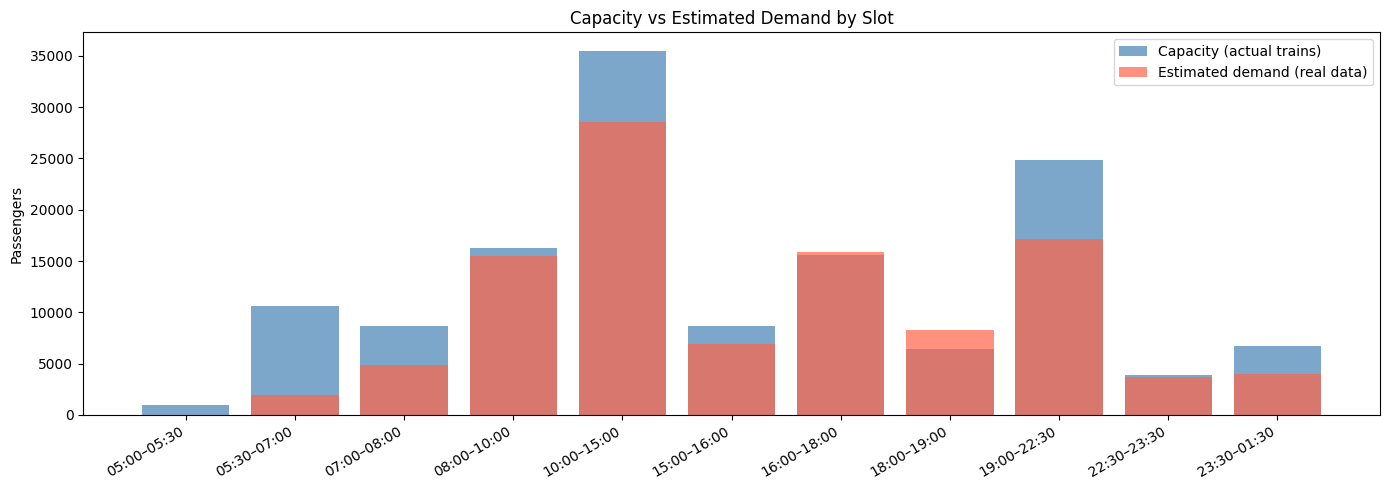

In [13]:
fig2, ax = plt.subplots(figsize=(14, 5))
x = range(len(avg_by_slot))
ax.bar(x, avg_by_slot["capacity_actual"], label="Capacity (actual trains)", color="steelblue", alpha=0.7)
ax.bar(x, avg_by_slot["estimated_demand"], label="Estimated demand (real data)", color="tomato", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(avg_by_slot.index, rotation=30, ha="right")
ax.set_title("Capacity vs Estimated Demand by Slot")
ax.set_ylabel("Passengers")
ax.legend()
plt.tight_layout()
plt.show()